In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


(1000, 8)

In [10]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [11]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')


In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

print(df_encoded.columns)

Index(['math score', 'reading score', 'writing score', 'gender_male',
       'race/ethnicity_group B', 'race/ethnicity_group C',
       'race/ethnicity_group D', 'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='str')


In [15]:
X = df_encoded.drop("math score", axis=1)

y = df_encoded["math score"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.24, 0.72,13.06,..., 0.76, 3.51, 3.29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['reading score','writing score','gender_male',..., 'parental level of education_some high school','lunch_standard', 'test preparation course_none']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-10.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14


In [18]:
predictions = model.predict(X_test)

print(predictions[:10])

[76.3879697  58.88597004 76.99026483 76.85180448 87.62737816 79.0140238
 64.65460865 53.00791885 74.18471015 49.21353815]


In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4.214763142474852
MSE: 29.095169866715494
R2 Score: 0.8804332983749564


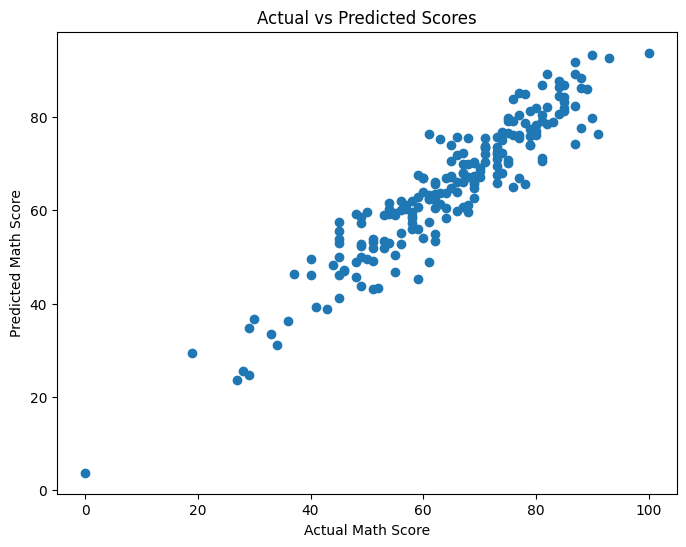

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")

plt.title("Actual vs Predicted Scores")

plt.savefig("../images/actual_vs_predicted.png", bbox_inches="tight")

plt.show()

In [21]:
corr = df_encoded.corr()

corr["math score"].sort_values(ascending=False)

math score                                       1.000000
reading score                                    0.817580
writing score                                    0.802642
lunch_standard                                   0.350877
race/ethnicity_group E                           0.205855
gender_male                                      0.167982
parental level of education_bachelor's degree    0.079664
parental level of education_master's degree      0.060417
race/ethnicity_group D                           0.050071
parental level of education_some college         0.037056
race/ethnicity_group C                          -0.073387
parental level of education_some high school    -0.079852
race/ethnicity_group B                          -0.084250
parental level of education_high school         -0.128725
test preparation course_none                    -0.177702
Name: math score, dtype: float64

In [22]:
import joblib

joblib.dump(model, "student_score_model.pkl")

['student_score_model.pkl']

In [24]:
model = joblib.load("student_score_model.pkl")
print("R2 Score:", r2)

R2 Score: 0.8804332983749564


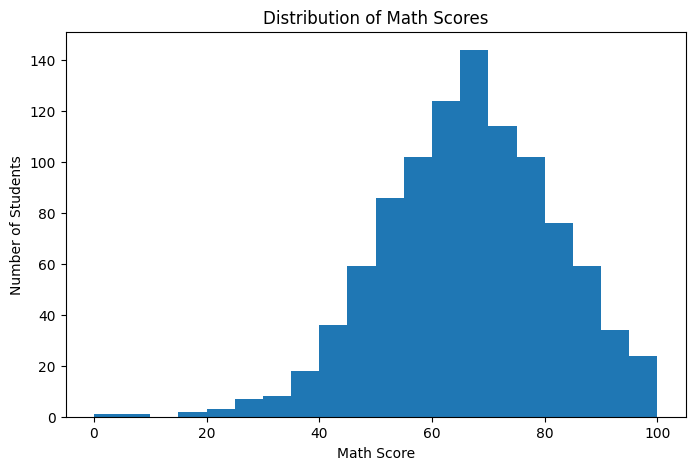

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["math score"], bins=20)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.savefig("../images/math_score_distribution.png", bbox_inches="tight")

plt.show()

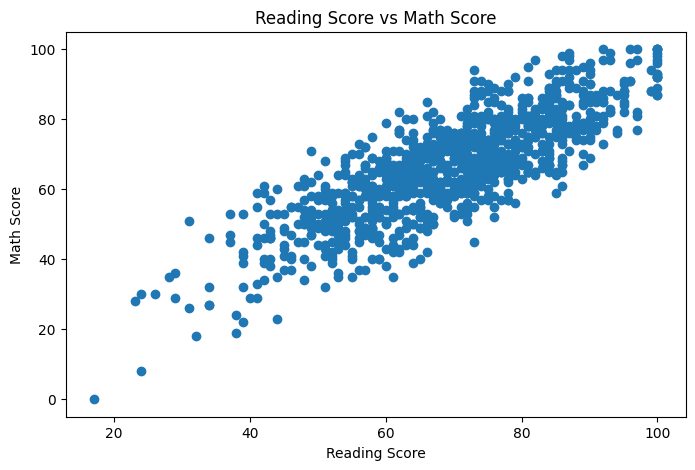

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(df["reading score"], df["math score"])

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Reading Score vs Math Score")

plt.savefig("../images/reading_vs_math.png", bbox_inches="tight")

plt.show()

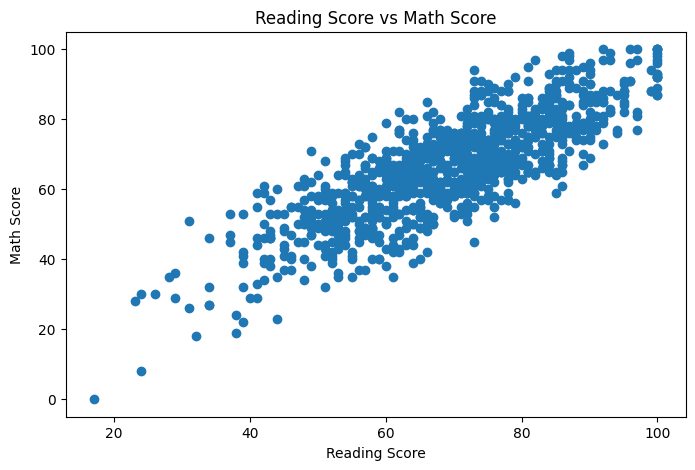

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(df["reading score"], df["math score"])

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Reading Score vs Math Score")

plt.show()

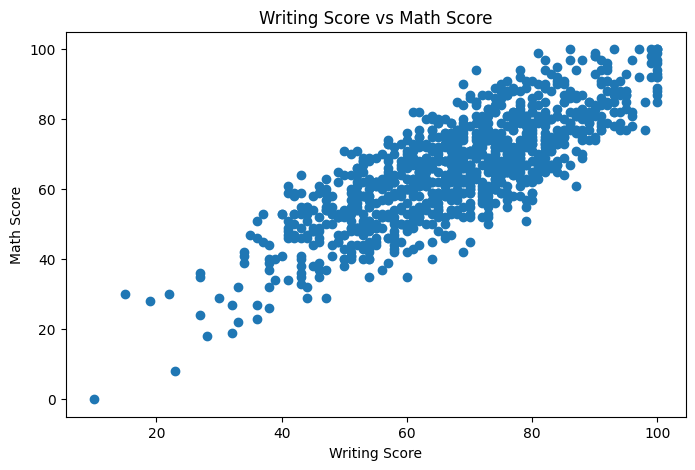

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(df["writing score"], df["math score"])

plt.xlabel("Writing Score")
plt.ylabel("Math Score")
plt.title("Writing Score vs Math Score")

plt.savefig("../images/writing_vs_math.png", bbox_inches="tight")

plt.show()